# Analysis of Dataset Obtained from the Harmonic Oscillator Simulation Lab

This report presents a detailed analysis of the data obtained from simulating the motion of a damped, driven simple pendulum. I investigate the kinematics (displacement, velocity, and acceleration), the energy flow (potential, kinetic, and total mechanical energy), the stability of the physical parameters (amplitude, period, frequency, and angular frequency) over time, and the phase-space trajectories of the system.

## List of constant parameters

The following parameters remain constant throughout the motion:
1. **Mass of the pendulum ($m$):** 1 kg
2. **Length of pendulum ($l$):** 3m
3. **Damping coefficient ($b$):** 0.05
4. **Driving torque amplitude ($\tau_d$):** 1Nm
5. **Driving frequency ($\omega_d$):** 1.8 rad/s
6. **Natural frequency ($\omega_0$):** 1.8 rad/s

# Initial Conditions
1. **Angular displacement ($\theta$):** 0.1 rad
2. **Angular velocity ($\dot{\theta}$):** 0.0 rad/s

## Kinematic Analysis


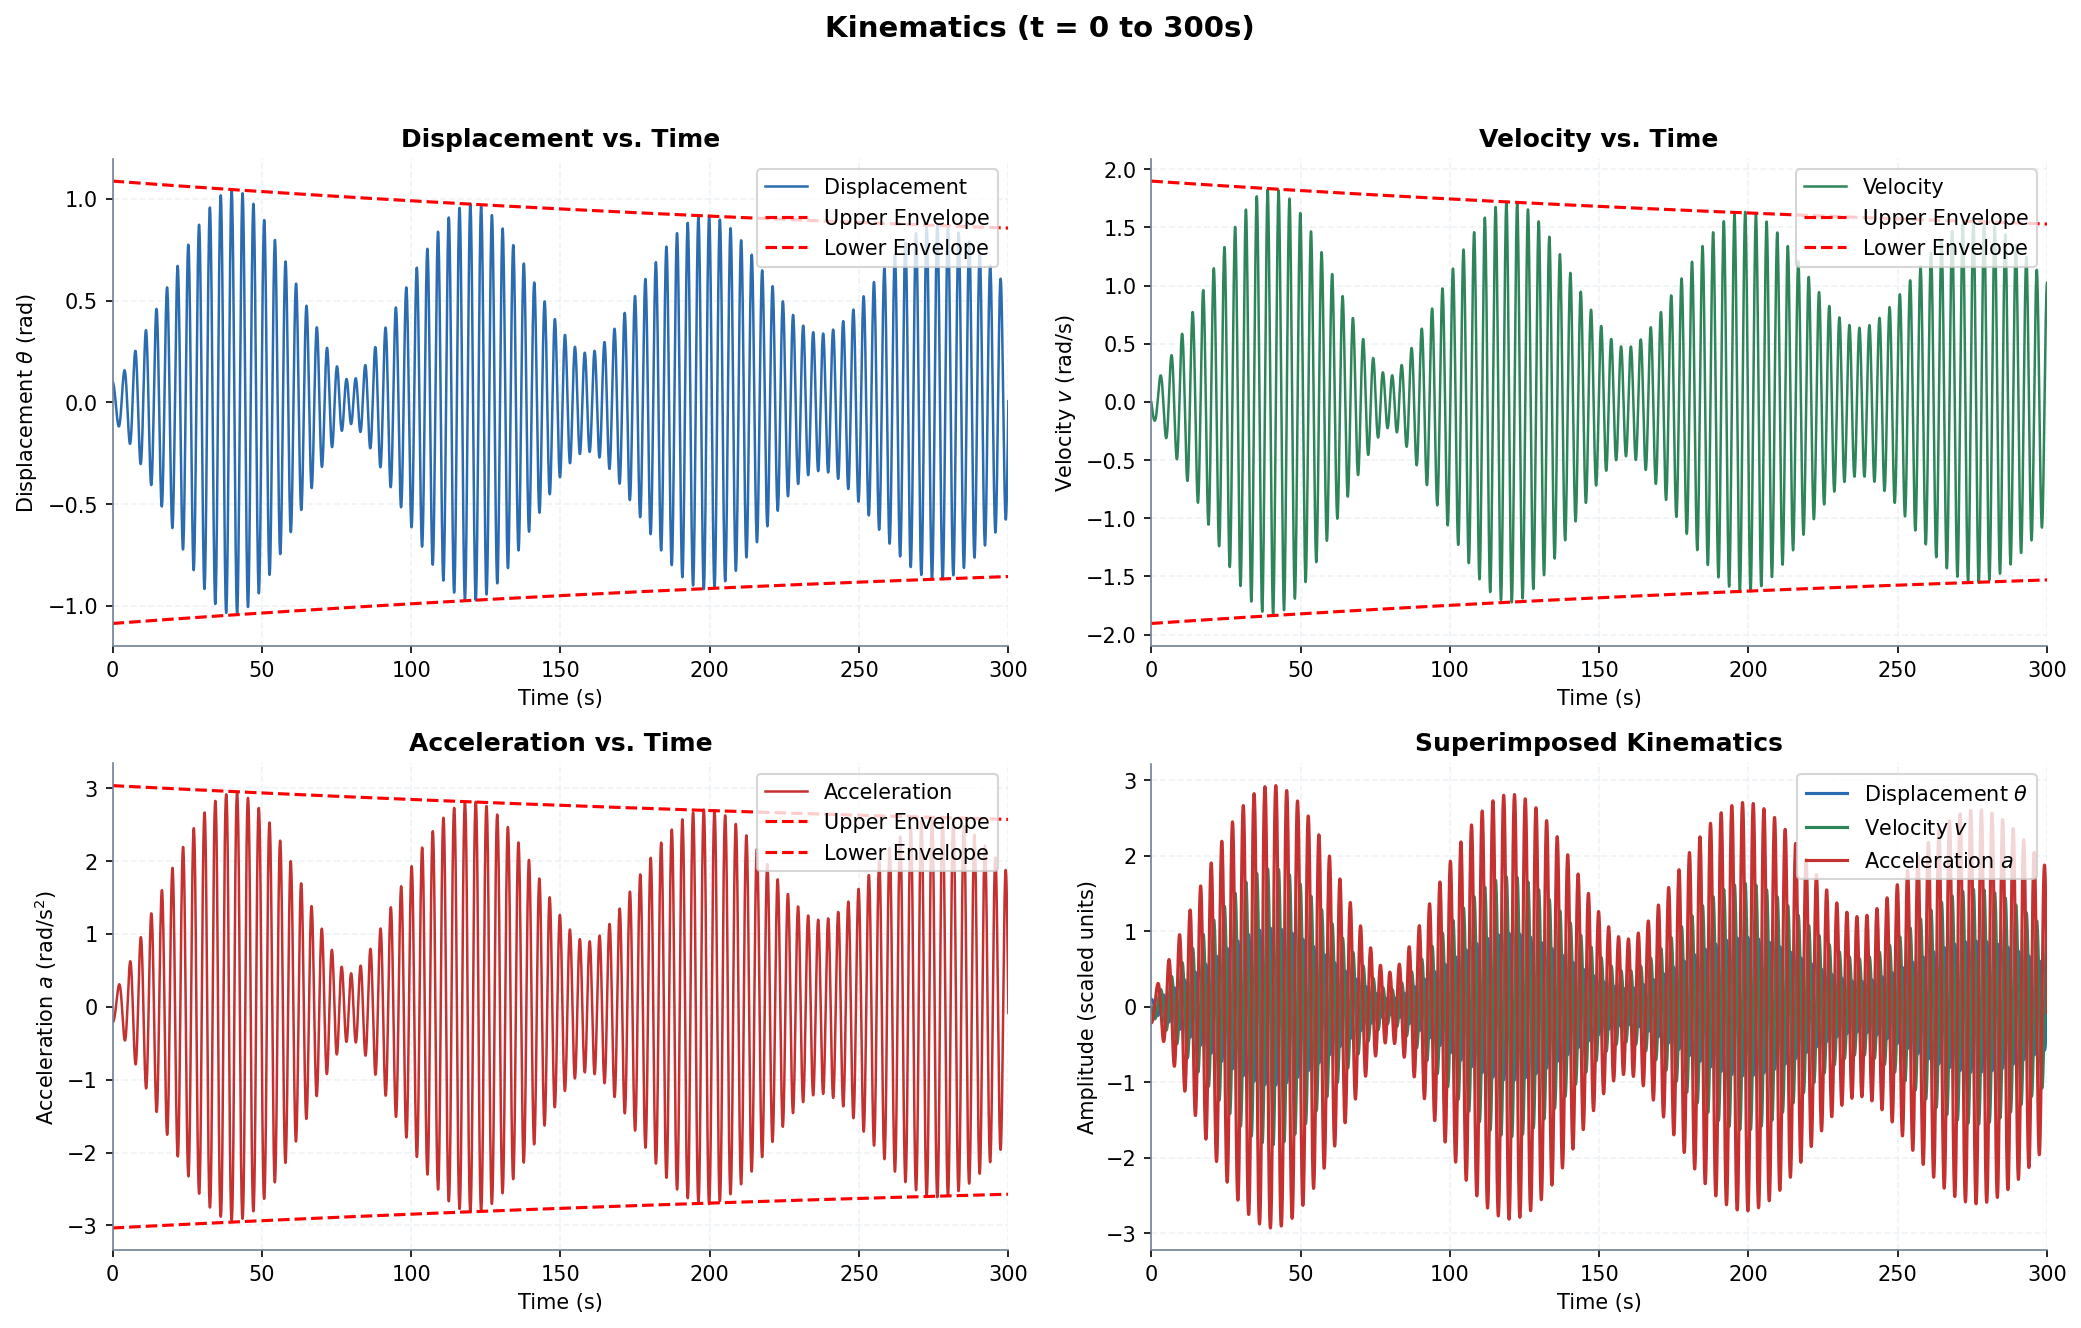
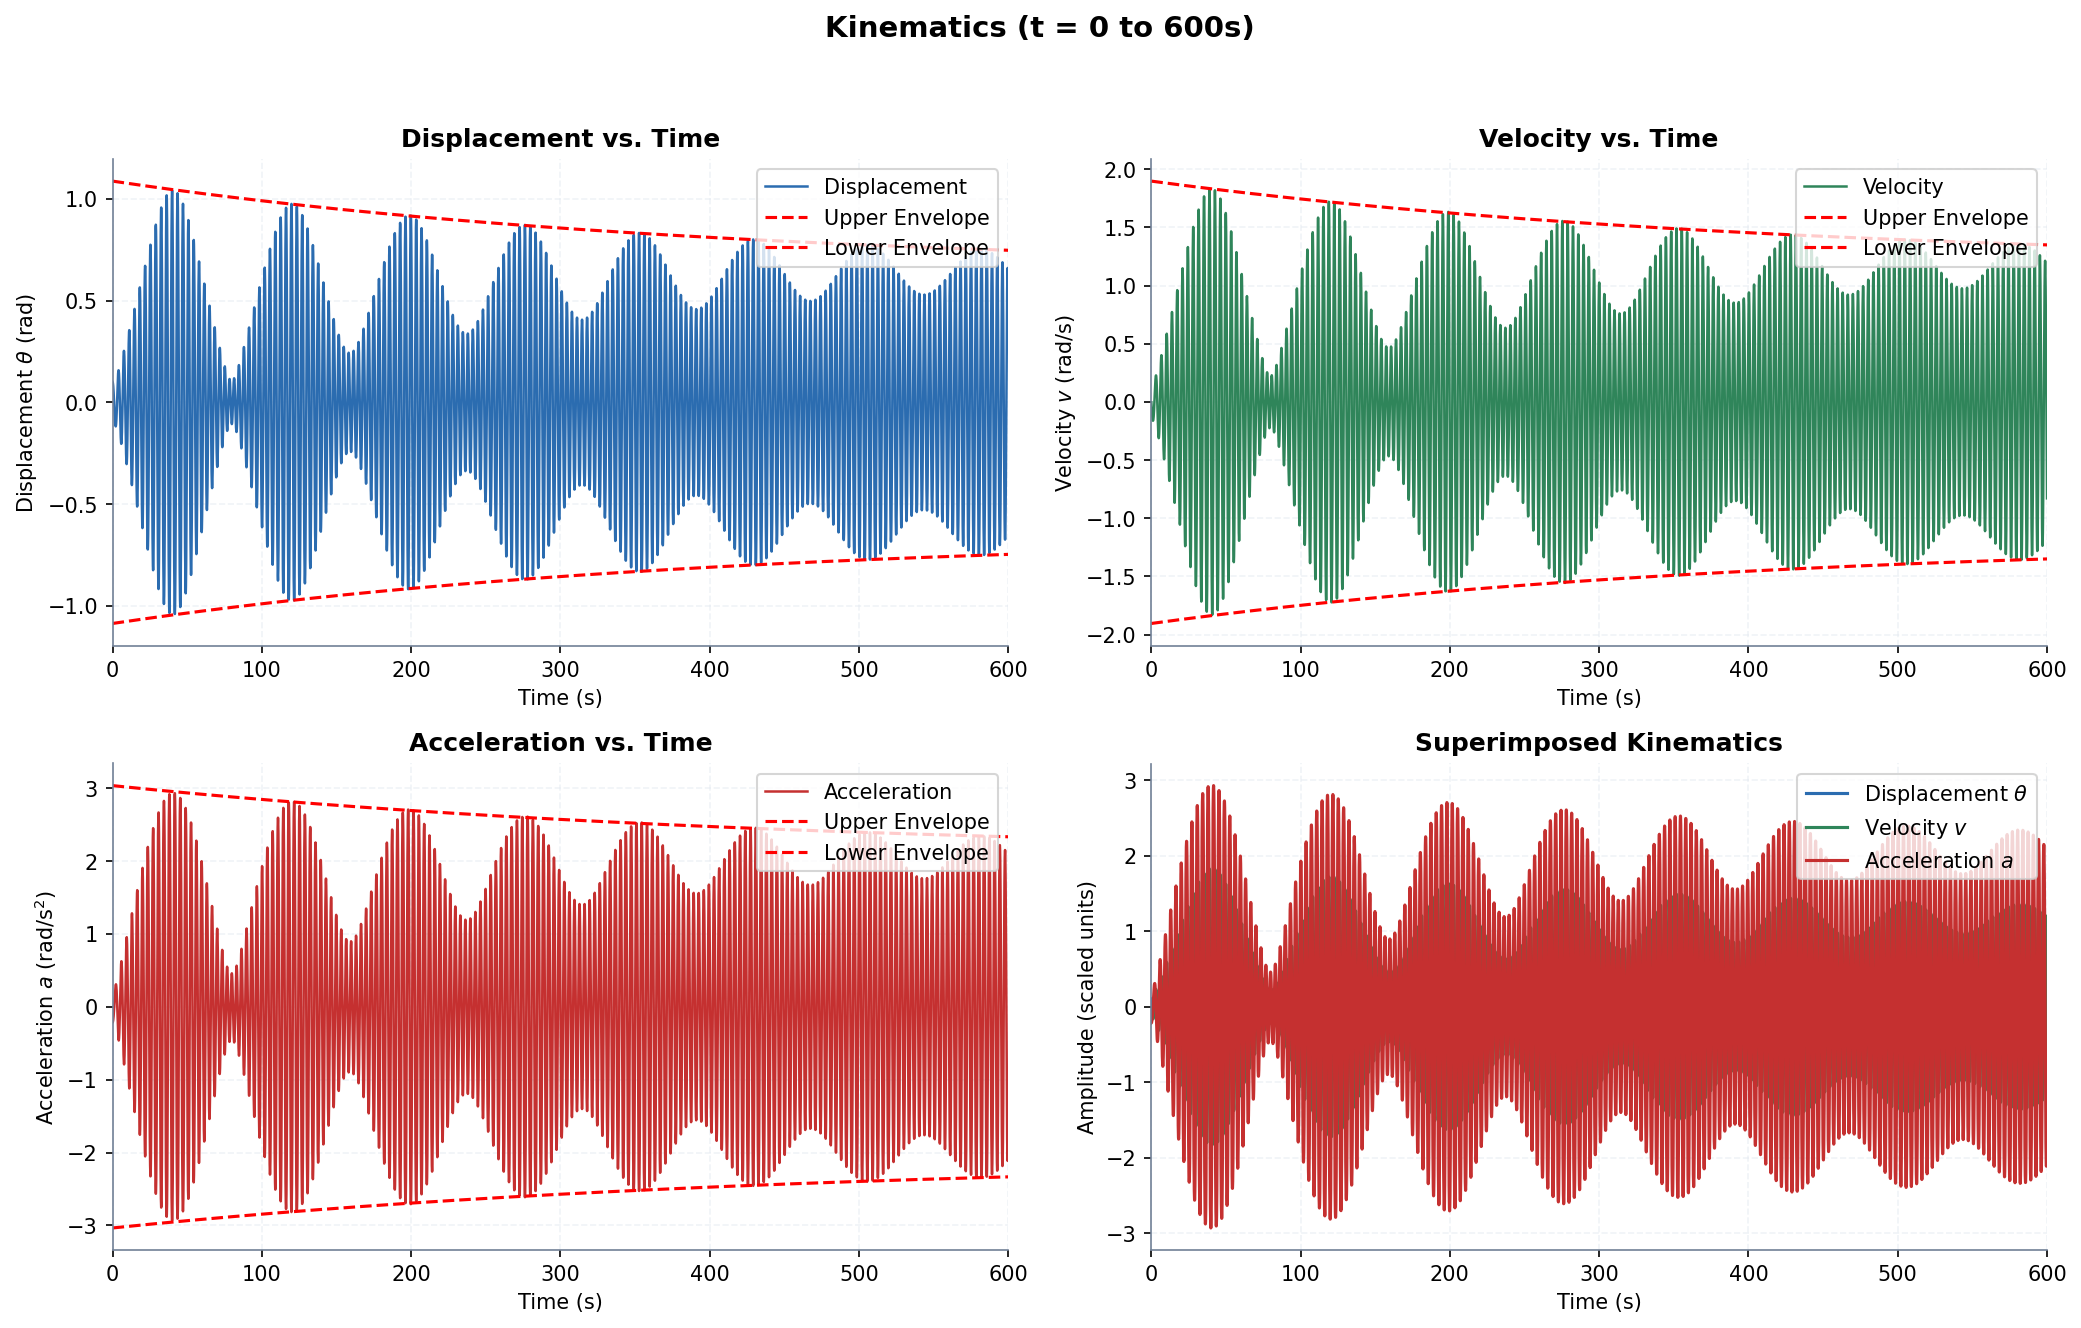
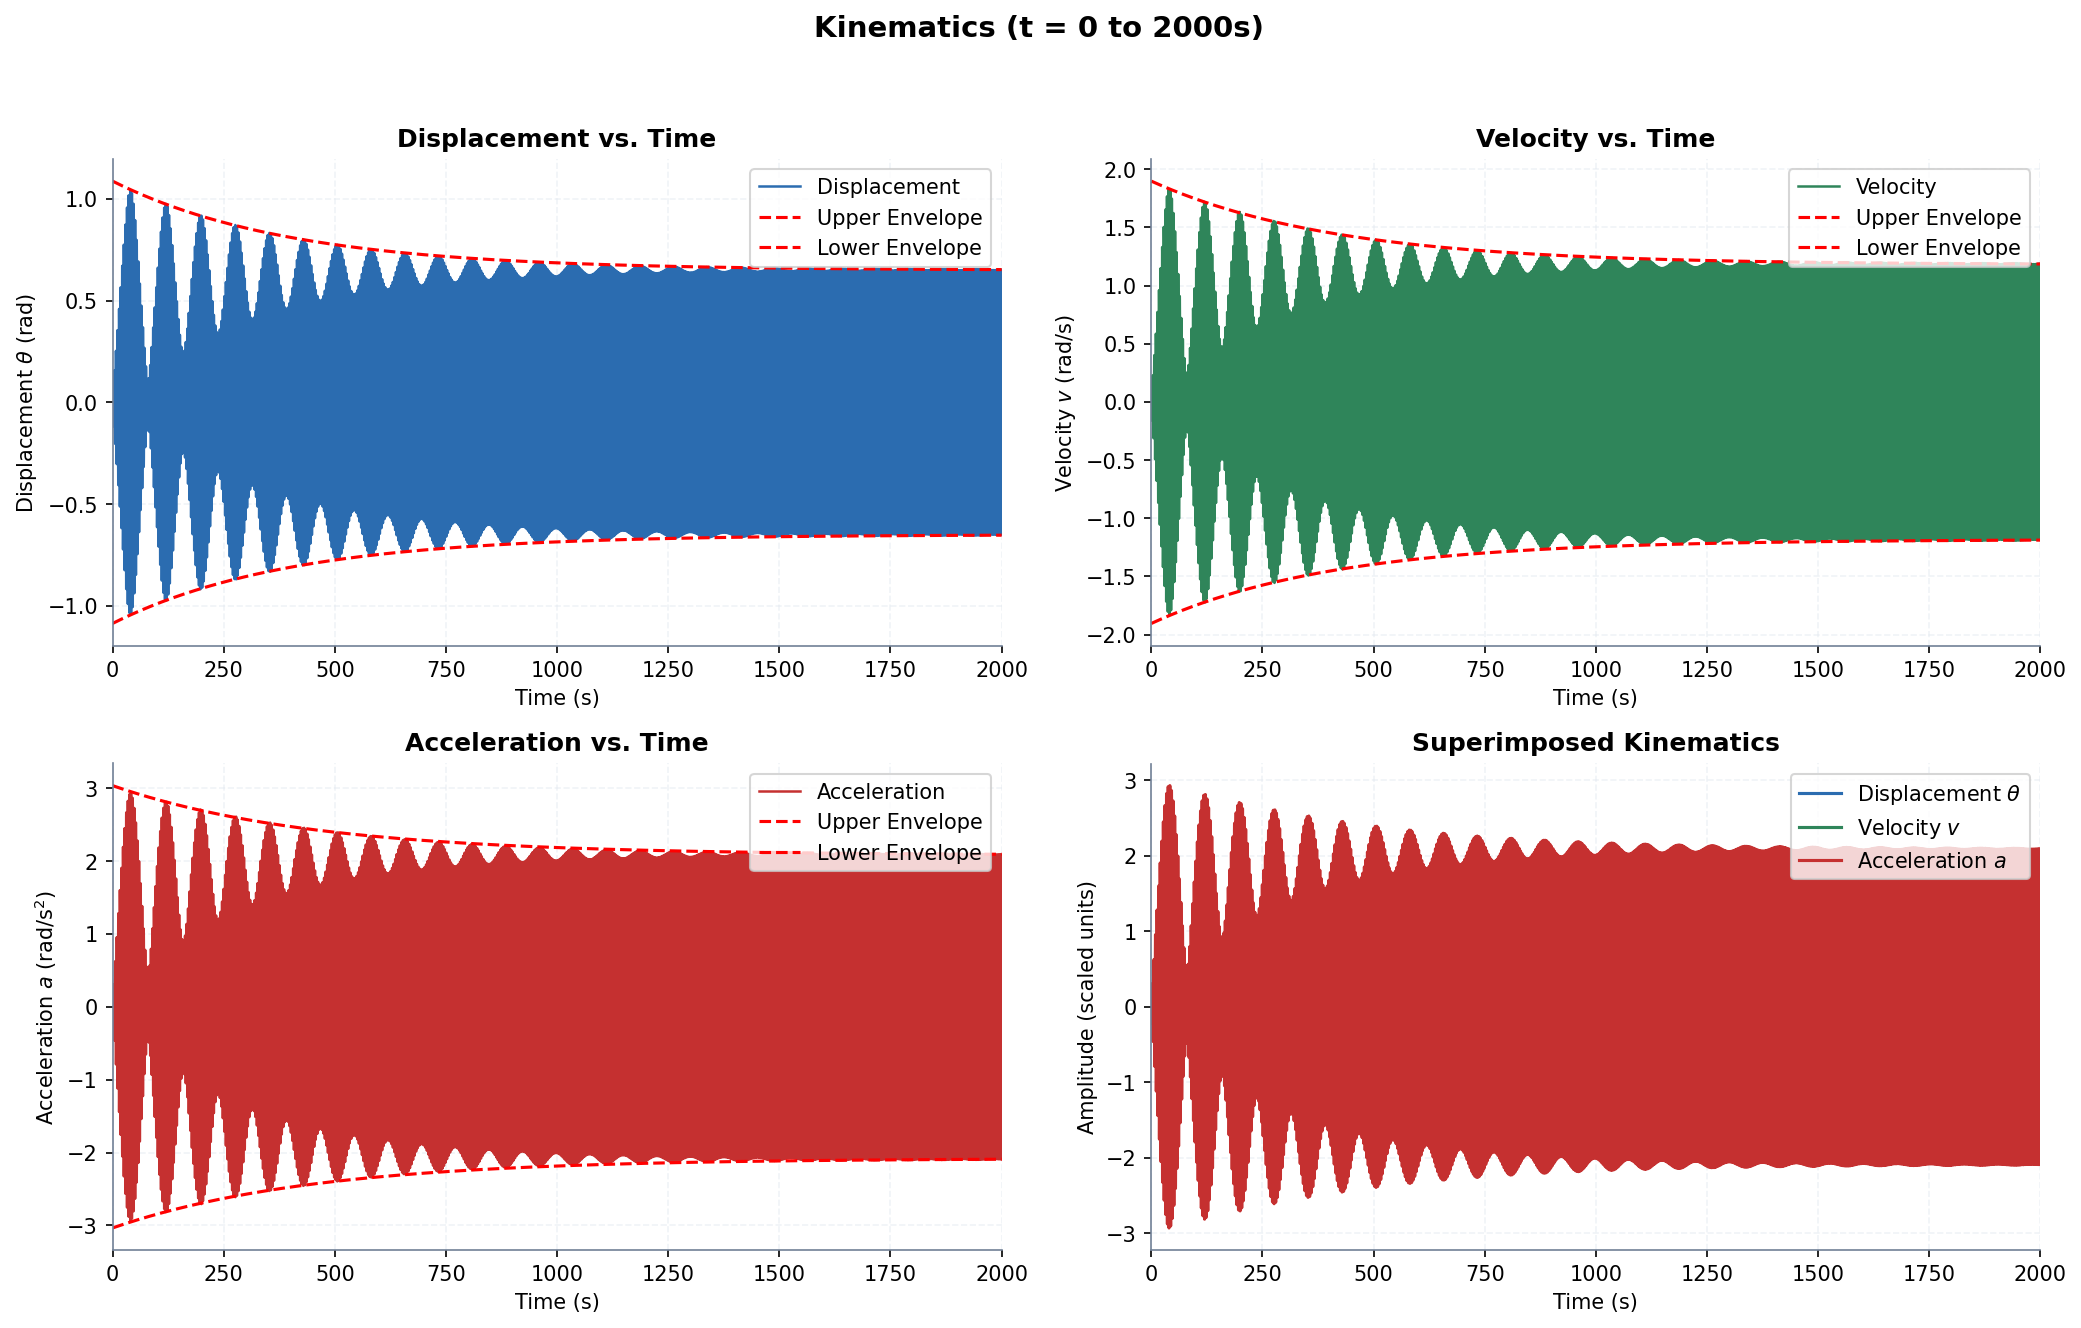

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#718096'
plt.rcParams['axes.grid'] = True

COLORS = {
    'displacement': '#2B6CB0',
    'velocity': '#2F855A',
    'acceleration': '#C53030',
    'potential': '#805AD5',
    'kinetic': '#DD6B20',
    'total_energy': '#2D3748',
    'grid': '#E2E8F0'
}

def exp_decay(t_val, A, B, C):
    return A * np.exp(-B * t_val) + C

def fit_envelope(t, y, label, distance=50):
    peaks_idx, _ = find_peaks(y, distance=distance)
    t_peaks = t[peaks_idx]
    y_peaks = y[peaks_idx]
    beat_max_idx, _ = find_peaks(y_peaks, distance=10)
    t_beat_max = t_peaks[beat_max_idx]
    y_beat_max = y_peaks[beat_max_idx]
    
    troughs_idx, _ = find_peaks(-y, distance=distance)
    t_troughs = t[troughs_idx]
    y_troughs = y[troughs_idx]
    beat_min_idx, _ = find_peaks(-y_troughs, distance=10)
    t_beat_min = t_troughs[beat_min_idx]
    y_beat_min = y_troughs[beat_min_idx]
    
    p0_guess = [0.4 * np.max(y), 0.003, 0.65 * np.max(y)]
    bounds_val = ([0, 0, 0], [2 * np.max(y), 1, 2 * np.max(y)])
    
    try:
        popt_peaks, _ = curve_fit(exp_decay, t_beat_max, y_beat_max, p0=p0_guess, bounds=bounds_val)
        upper = exp_decay(t, *popt_peaks)
    except:
        upper = None
        
    try:
        popt_troughs, _ = curve_fit(exp_decay, t_beat_min, -y_beat_min, p0=p0_guess, bounds=bounds_val)
        lower = -exp_decay(t, *popt_troughs)
    except:
        lower = None
        
    return upper, lower

# Load data
df_theta = pd.read_csv("data/t_vs_theta.csv")
df_v = pd.read_csv("data/t_vs_v.csv")
df_accel = pd.read_csv("data/t_vs_accel.csv")
t = df_theta["t"].values
theta = df_theta["theta"].values
v = df_v["v"].values
accel = df_accel["accel"].values

theta_upper, theta_lower = fit_envelope(t, theta, "Displacement", distance=50)
v_upper, v_lower = fit_envelope(t, v, "Velocity", distance=50)
accel_upper, accel_lower = fit_envelope(t, accel, "Acceleration", distance=50)

t_limits = [300, 600, 2000]
kin_files = []
for t_max in t_limits:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax in axes.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.5, color=COLORS['grid'])
        
    # Displacement
    axes[0, 0].plot(t, theta, color=COLORS['displacement'], linewidth=1.2, label='Displacement')
    if theta_upper is not None:
        axes[0, 0].plot(t, theta_upper, 'r--', linewidth=1.5, label='Upper Envelope')
    if theta_lower is not None:
        axes[0, 0].plot(t, theta_lower, 'r--', linewidth=1.5, label='Lower Envelope')
    axes[0, 0].set_title('Displacement vs. Time', fontweight='bold')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel(r'Displacement $\theta$ (rad)')
    axes[0, 0].set_xlim(0, t_max)
    axes[0, 0].legend(loc='upper right')
    
    # Velocity
    axes[0, 1].plot(t, v, color=COLORS['velocity'], linewidth=1.2, label='Velocity')
    if v_upper is not None:
        axes[0, 1].plot(t, v_upper, 'r--', linewidth=1.5, label='Upper Envelope')
    if v_lower is not None:
        axes[0, 1].plot(t, v_lower, 'r--', linewidth=1.5, label='Lower Envelope')
    axes[0, 1].set_title('Velocity vs. Time', fontweight='bold')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel(r'Velocity $v$ (rad/s)')
    axes[0, 1].set_xlim(0, t_max)
    axes[0, 1].legend(loc='upper right')
    
    # Acceleration
    axes[1, 0].plot(t, accel, color=COLORS['acceleration'], linewidth=1.2, label='Acceleration')
    if accel_upper is not None:
        axes[1, 0].plot(t, accel_upper, 'r--', linewidth=1.5, label='Upper Envelope')
    if accel_lower is not None:
        axes[1, 0].plot(t, accel_lower, 'r--', linewidth=1.5, label='Lower Envelope')
    axes[1, 0].set_title('Acceleration vs. Time', fontweight='bold')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel(r'Acceleration $a$ (rad/s$^2$)')
    axes[1, 0].set_xlim(0, t_max)
    axes[1, 0].legend(loc='upper right')
    
    # Superimposed
    axes[1, 1].plot(t, theta, color=COLORS['displacement'], label=r'Displacement $\theta$')
    axes[1, 1].plot(t, v, color=COLORS['velocity'], label=r'Velocity $v$')
    axes[1, 1].plot(t, accel, color=COLORS['acceleration'], label=r'Acceleration $a$')
    axes[1, 1].set_title('Superimposed Kinematics', fontweight='bold')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Amplitude (scaled units)')
    axes[1, 1].set_xlim(0, t_max)
    axes[1, 1].legend(loc='upper right')
    
    fig.suptitle(f'Kinematics (t = 0 to {t_max}s)', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fn = f"plots/displacement_nb_0_{t_max}.png"
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.close(fig)
    kin_files.append(fn)

# Carousel function
carousel_code_here = """
carousel_display_code
"""
import base64
import random
from IPython.display import HTML, display

def display_carousel(image_paths, captions):
    html_str = """
    <style>
    .slider-container {
        position: relative;
        max-width: 900px;
        margin: 20px auto;
        overflow: hidden;
        border: 1px solid #E2E8F0;
        border-radius: 12px;
        box-shadow: 0 10px 25px rgba(0,0,0,0.08);
        background: #F8FAFC;
    }
    .slides-wrapper {
        display: flex;
        transition: transform 0.4s cubic-bezier(0.4, 0, 0.2, 1);
    }
    .slide {
        min-width: 100%;
        box-sizing: border-box;
        text-align: center;
        padding: 15px;
    }
    .slide img {
        width: 100%;
        height: auto;
        max-height: 550px;
        object-fit: contain;
        border-radius: 8px;
    }
    .caption {
        padding: 12px;
        font-family: 'Inter', -apple-system, sans-serif;
        font-size: 14px;
        color: #4A5568;
        font-weight: 600;
        background: #FFFFFF;
        border-top: 1px solid #EDF2F7;
        margin-top: 10px;
    }
    .prev-btn, .next-btn {
        position: absolute;
        top: 50%;
        transform: translateY(-50%);
        background-color: rgba(45, 55, 72, 0.75);
        color: white;
        border: none;
        width: 44px;
        height: 44px;
        cursor: pointer;
        border-radius: 50%;
        font-size: 20px;
        user-select: none;
        display: flex;
        align-items: center;
        justify-content: center;
        transition: all 0.2s ease;
    }
    .prev-btn { left: 15px; }
    .next-btn { right: 15px; }
    .prev-btn:hover, .next-btn:hover {
        background-color: rgba(26, 32, 44, 0.95);
        transform: translateY(-50%) scale(1.05);
    }
    .dots-container {
        text-align: center;
        padding: 12px;
        background: #FFFFFF;
        border-top: 1px solid #EDF2F7;
    }
    .dot {
        cursor: pointer;
        height: 10px;
        width: 10px;
        margin: 0 5px;
        background-color: #CBD5E0;
        border-radius: 50%;
        display: inline-block;
        transition: all 0.3s ease;
    }
    .active-dot, .dot:hover {
        background-color: #4A5568;
        transform: scale(1.2);
    }
    </style>
    """
    
    slider_id = f"slider_{random.randint(1000, 9999)}"
    
    html_str += f'<div class="slider-container" id="{slider_id}">'
    html_str += '<div class="slides-wrapper">'
    
    for path, caption in zip(image_paths, captions):
        try:
            with open(path, "rb") as image_file:
                b64_data = base64.b64encode(image_file.read()).decode("utf-8")
            img_src = f"data:image/png;base64,{b64_data}"
        except Exception:
            img_src = path
            
        html_str += f'<div class="slide"><img src="{img_src}"><div class="caption">{caption}</div></div>'
        
    html_str += '</div>'
    html_str += f'<button class="prev-btn" onclick="{slider_id}_move(-1)">&#10094;</button>'
    html_str += f'<button class="next-btn" onclick="{slider_id}_move(1)">&#10095;</button>'
    
    html_str += '<div class="dots-container">'
    for i in range(len(image_paths)):
        html_str += f'<span class="dot" id="{slider_id}_dot_{i}" onclick="{slider_id}_goto({i})"></span>'
    html_str += '</div>'
    html_str += '</div>'
    
    html_str += f"""
    <script>
    (function() {{
        var idx = 0;
        var slides = document.querySelectorAll('#{slider_id} .slide');
        var wrapper = document.querySelector('#{slider_id} .slides-wrapper');
        var dots = document.querySelectorAll('#{slider_id} .dot');
        
        function update() {{
            wrapper.style.transform = 'translateX(' + (-idx * 100) + '%)';
            dots.forEach(function(dot, i) {{
                if (i === idx) dot.classList.add('active-dot');
                else dot.classList.remove('active-dot');
            }});
        }}
        
        window.{slider_id}_move = function(n) {{
            idx = (idx + n + slides.length) % slides.length;
            update();
        }};
        
        window.{slider_id}_goto = function(n) {{
            idx = n;
            update();
        }};
        
        update();
    }})();
    </script>
    """
    display(HTML(html_str))

display_carousel(kin_files, [f'Kinematics (0 to {x}s)' for x in t_limits])

### Observations
- The data set can be divided into regions at varying intervals called beats.
- The peaks of these regions are decreasing as well as their width.
- Fitting a trend line, we see that the crests and troughs of the beats approach a constant value and the beats fuse into one.


## Energy Analysis


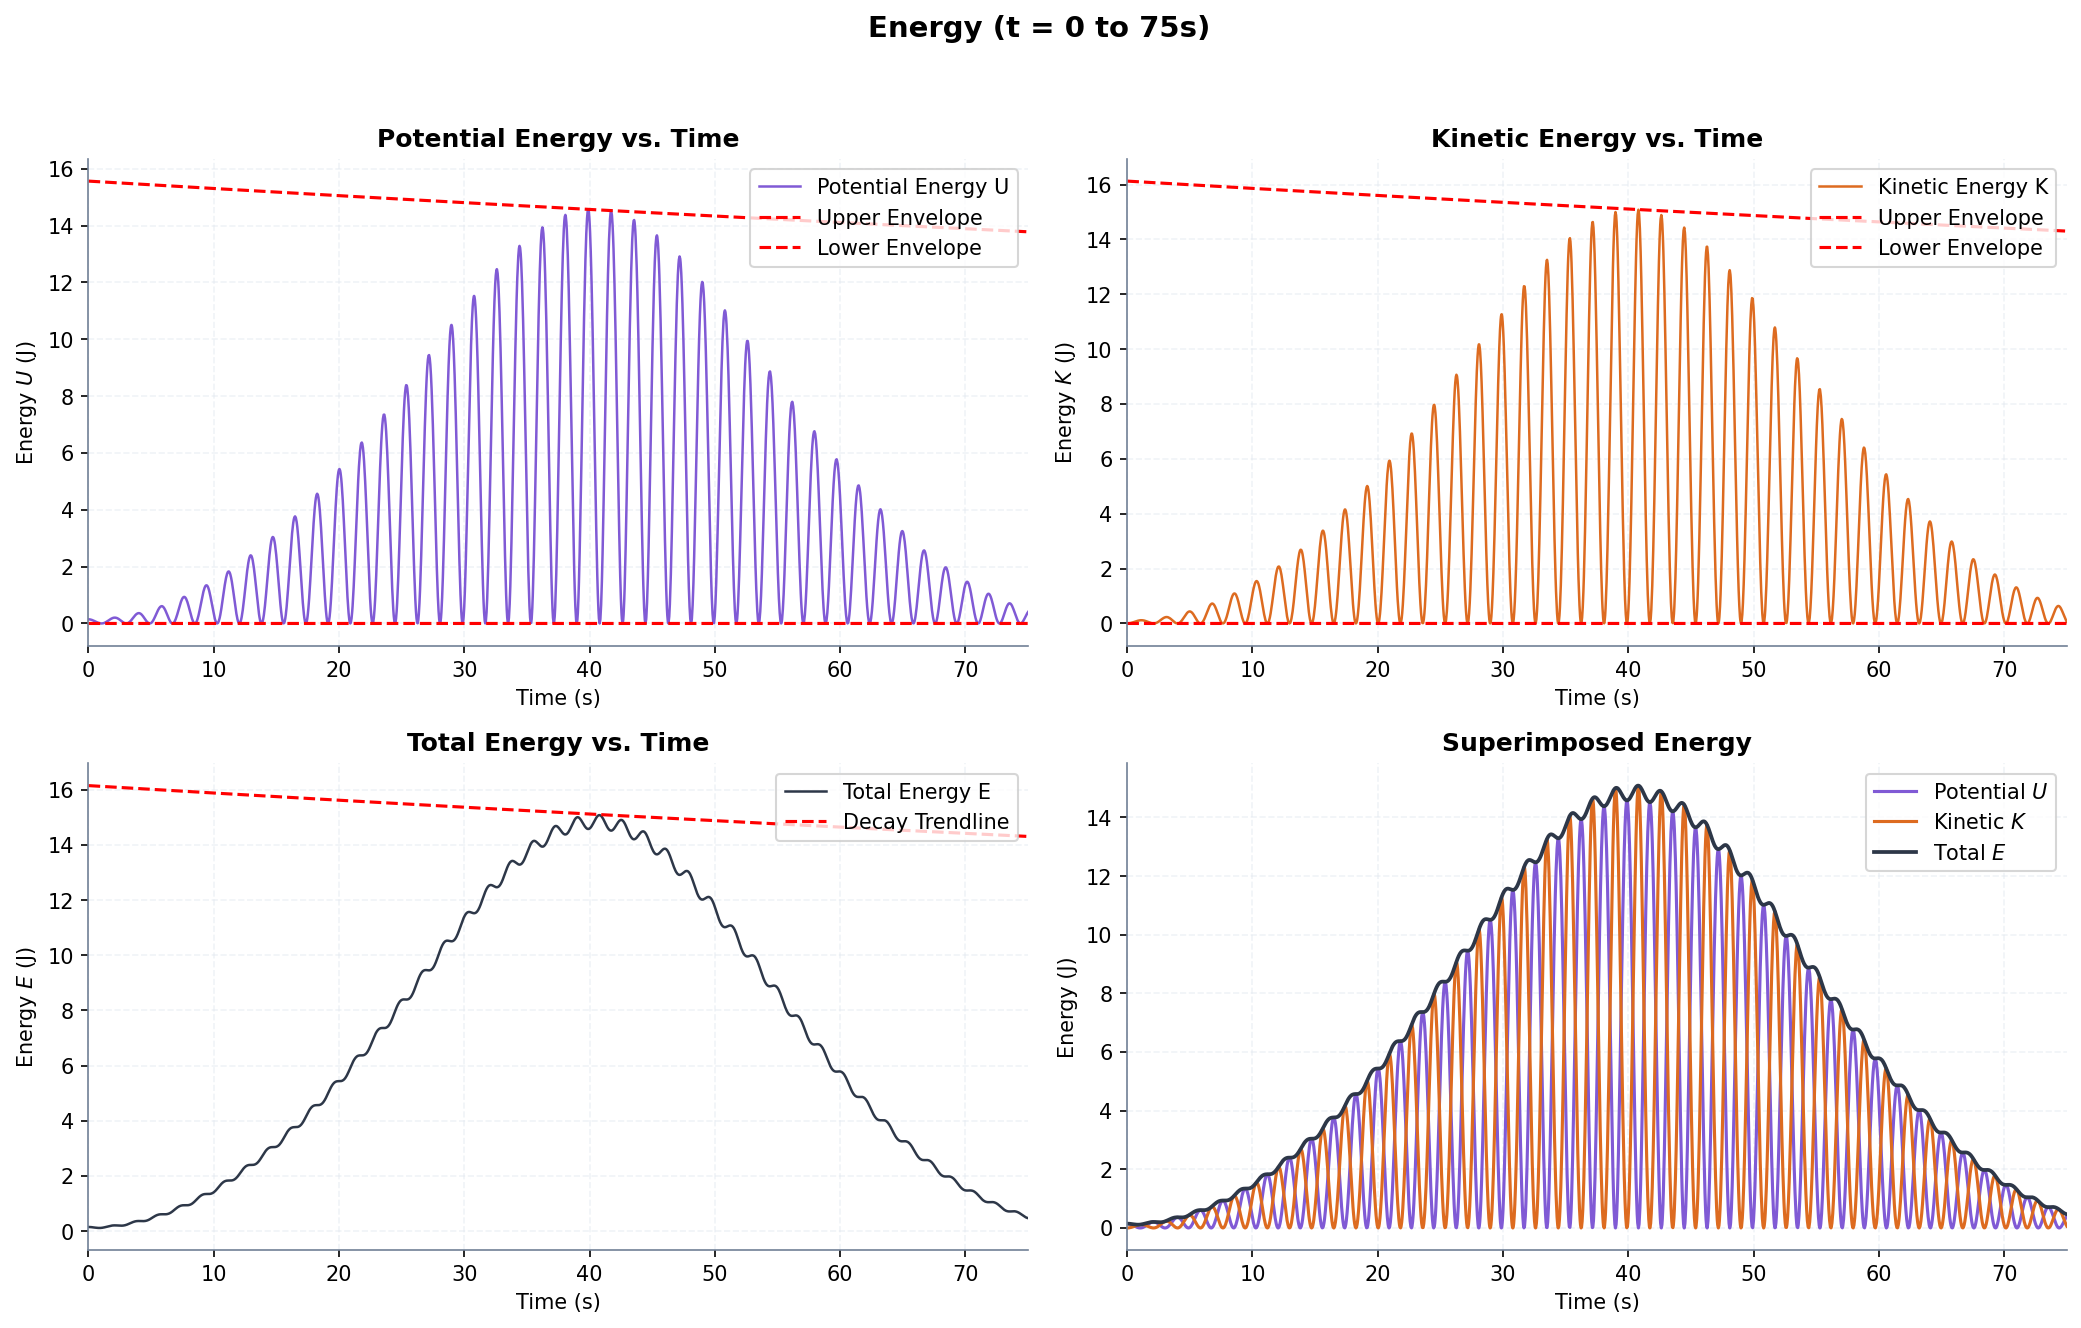
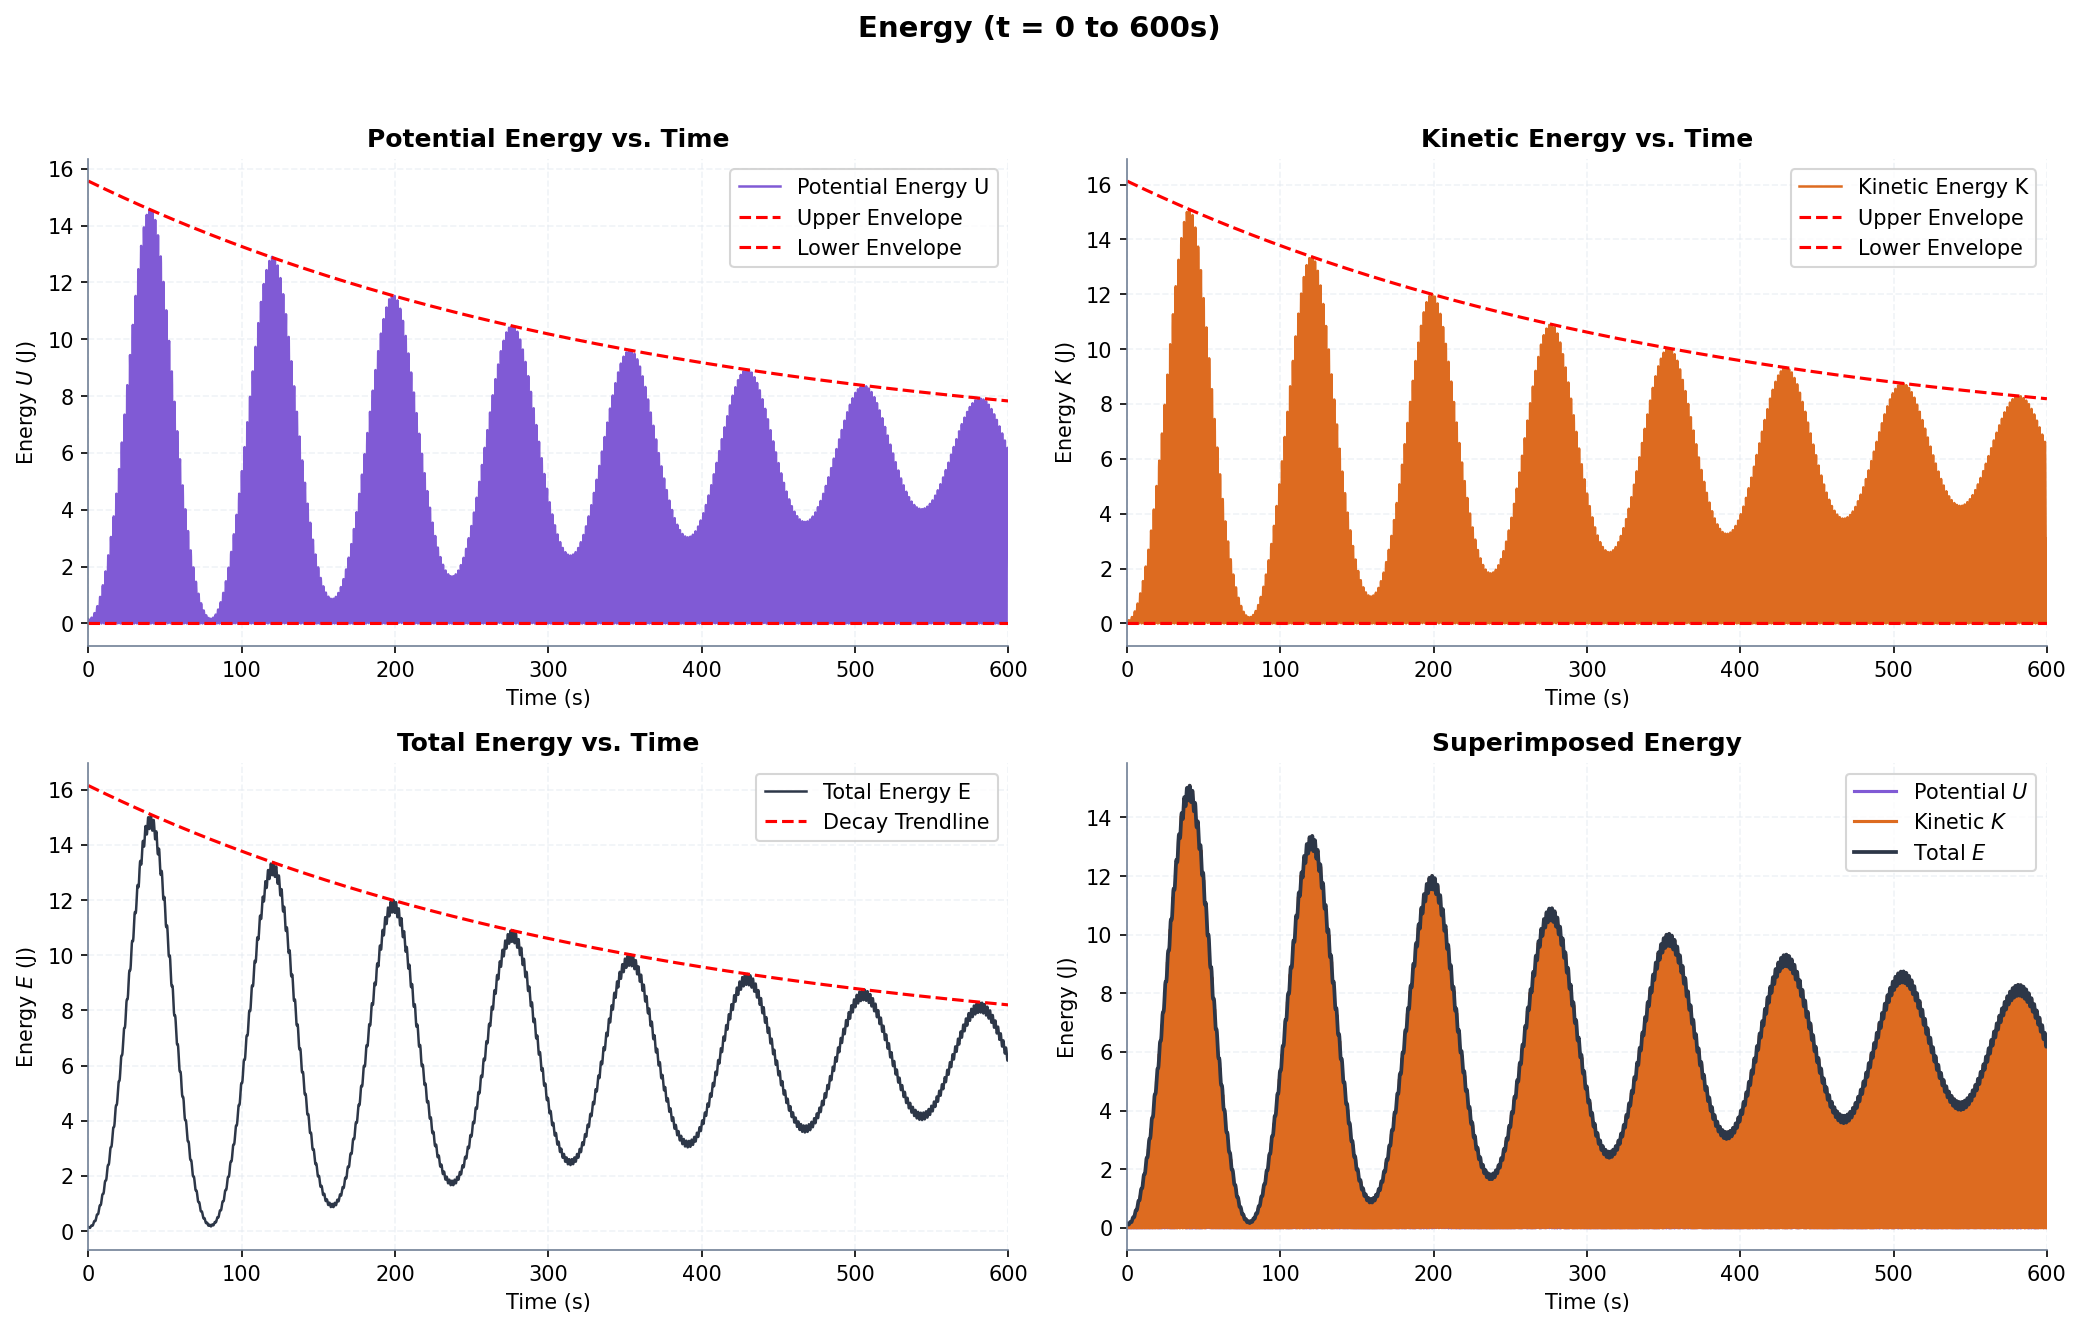
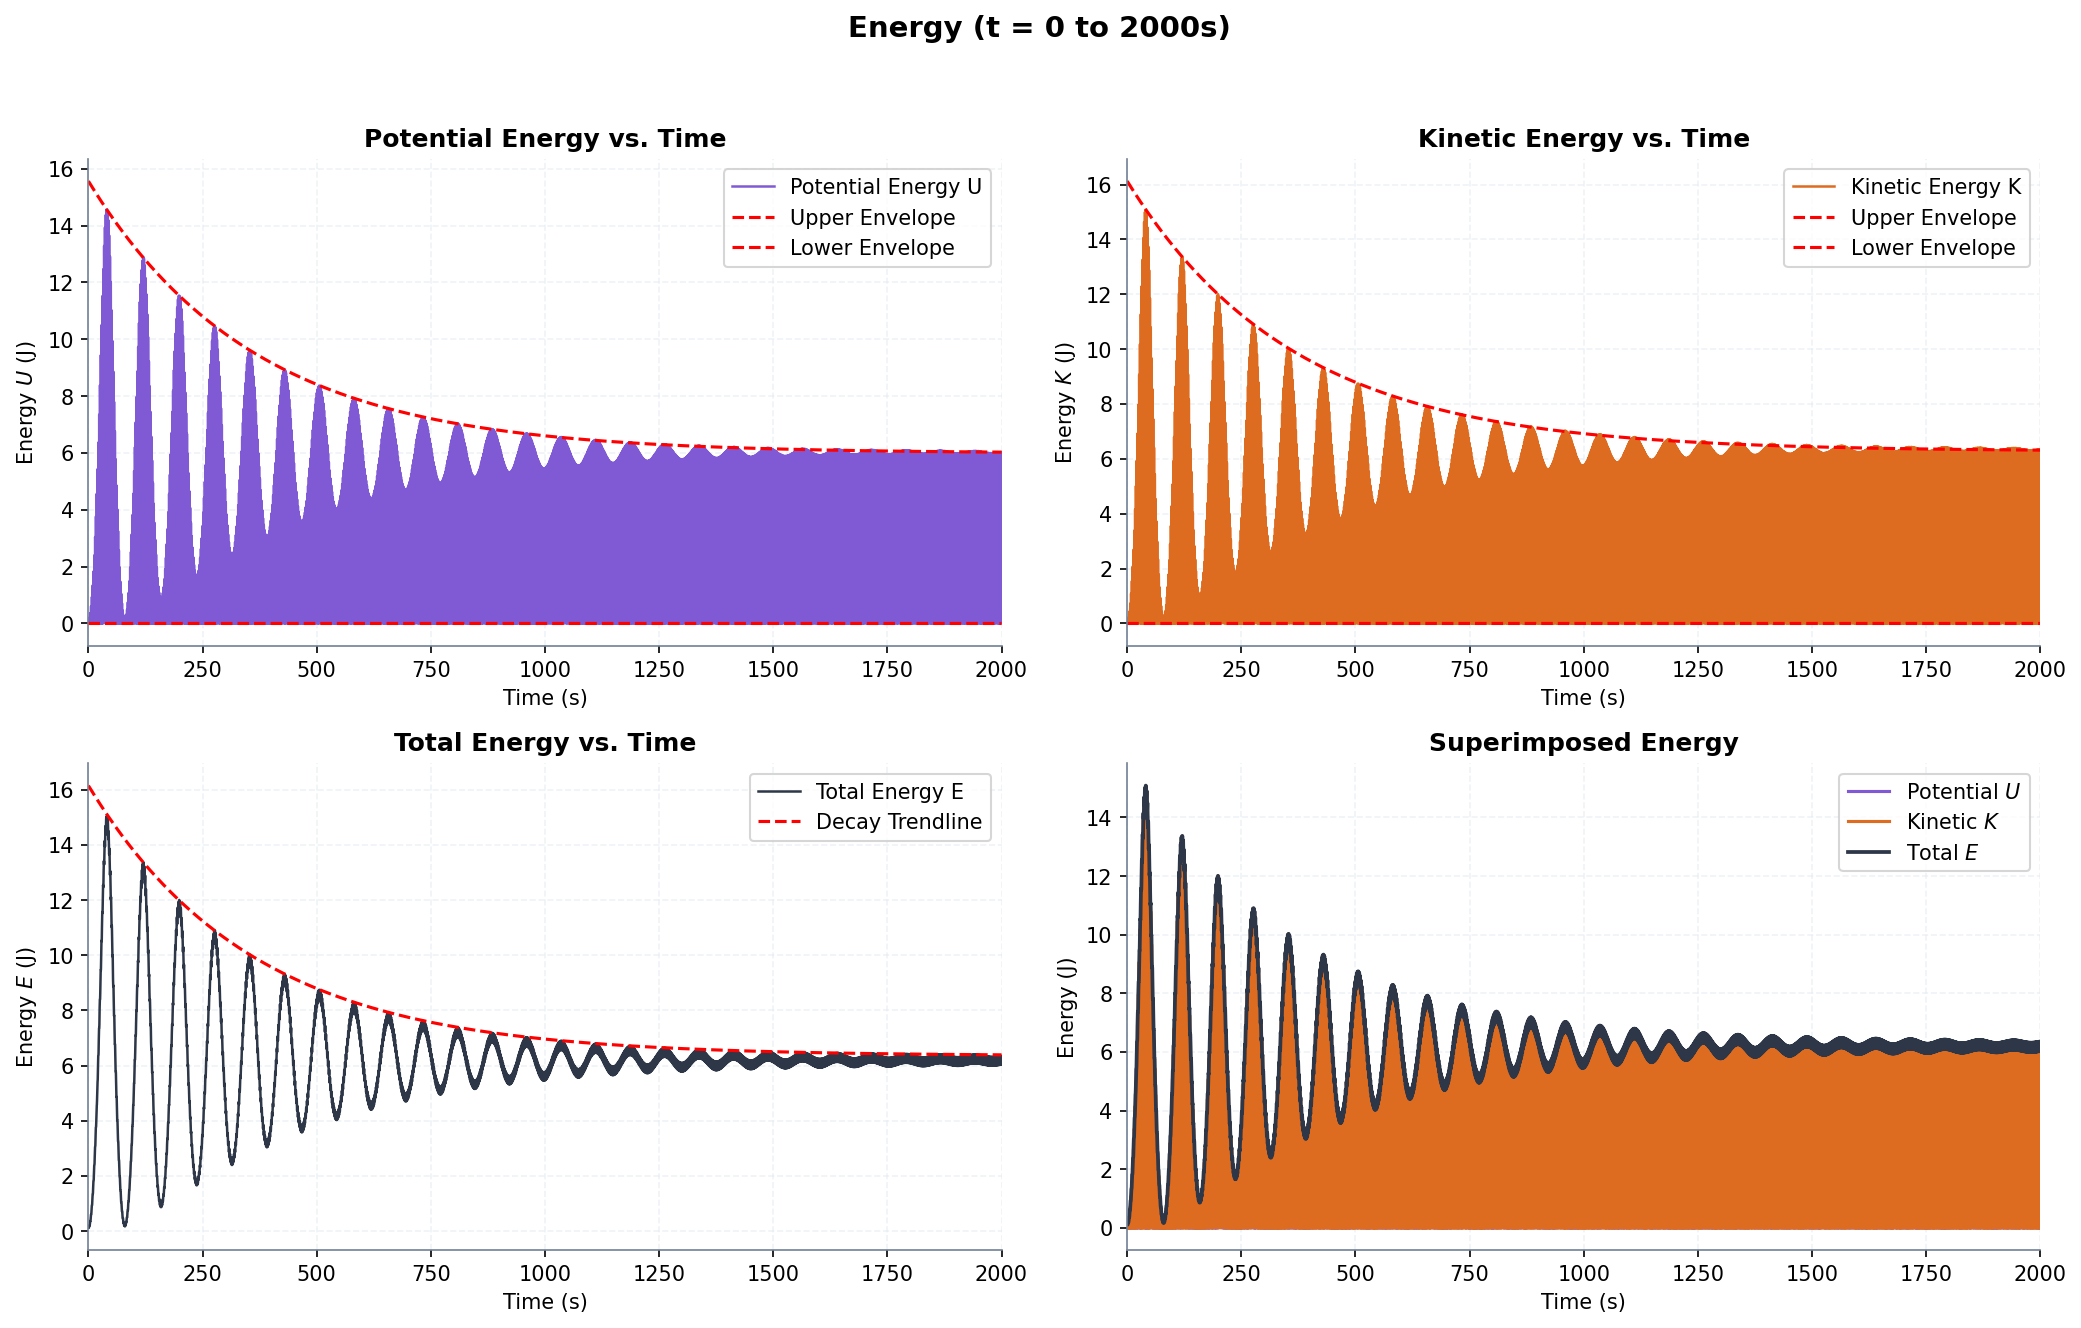

In [2]:
# Load energy data
df_U = pd.read_csv("data/t_vs_U.csv")
df_K = pd.read_csv("data/t_vs_K.csv")
df_E = pd.read_csv("data/t_vs_E.csv")
U = df_U["U"].values
K = df_K["K"].values
E = df_E["E"].values

U_upper, U_lower = fit_envelope(t, U, "Potential Energy", distance=25)
K_upper, K_lower = fit_envelope(t, K, "Kinetic Energy", distance=25)
E_upper, _ = fit_envelope(t, E, "Total Energy", distance=25)

en_limits = [75, 600, 2000]
en_files = []
for t_max in en_limits:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax in axes.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.5, color=COLORS['grid'])
        
    # Potential Energy
    axes[0, 0].plot(t, U, color=COLORS['potential'], linewidth=1.2, label='Potential Energy U')
    if U_upper is not None:
        axes[0, 0].plot(t, U_upper, 'r--', linewidth=1.5, label='Upper Envelope')
    if U_lower is not None:
        axes[0, 0].plot(t, U_lower, 'r--', linewidth=1.5, label='Lower Envelope')
    axes[0, 0].set_title('Potential Energy vs. Time', fontweight='bold')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Energy $U$ (J)')
    axes[0, 0].set_xlim(0, t_max)
    axes[0, 0].legend(loc='upper right')
    
    # Kinetic Energy
    axes[0, 1].plot(t, K, color=COLORS['kinetic'], linewidth=1.2, label='Kinetic Energy K')
    if K_upper is not None:
        axes[0, 1].plot(t, K_upper, 'r--', linewidth=1.5, label='Upper Envelope')
    if K_lower is not None:
        axes[0, 1].plot(t, K_lower, 'r--', linewidth=1.5, label='Lower Envelope')
    axes[0, 1].set_title('Kinetic Energy vs. Time', fontweight='bold')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Energy $K$ (J)')
    axes[0, 1].set_xlim(0, t_max)
    axes[0, 1].legend(loc='upper right')
    
    # Total Energy
    axes[1, 0].plot(t, E, color=COLORS['total_energy'], linewidth=1.2, label='Total Energy E')
    if E_upper is not None:
        axes[1, 0].plot(t, E_upper, 'r--', linewidth=1.5, label='Decay Trendline')
    axes[1, 0].set_title('Total Energy vs. Time', fontweight='bold')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Energy $E$ (J)')
    axes[1, 0].set_xlim(0, t_max)
    axes[1, 0].legend(loc='upper right')
    
    # Superimposed
    axes[1, 1].plot(t, U, color=COLORS['potential'], label='Potential $U$')
    axes[1, 1].plot(t, K, color=COLORS['kinetic'], label='Kinetic $K$')
    axes[1, 1].plot(t, E, color=COLORS['total_energy'], linewidth=1.8, label='Total $E$')
    axes[1, 1].set_title('Superimposed Energy', fontweight='bold')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Energy (J)')
    axes[1, 1].set_xlim(0, t_max)
    axes[1, 1].legend(loc='upper right')
    
    fig.suptitle(f'Energy (t = 0 to {t_max}s)', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fn = f"plots/energy_nb_0_{t_max}.png"
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.close(fig)
    en_files.append(fn)

display_carousel(en_files, [f'Energy (0 to {x}s)' for x in en_limits])

### Observations
- Mechanical energy oscillates between kinetic and potential.
- Peaks of kinetic and potential energies approach a constant value as t goes to infinity.
- Total energy crests and troughs are shrunk by the damping effect from above and the driving force from below to approach a constant value of about 6J.


## System Parameters Analysis


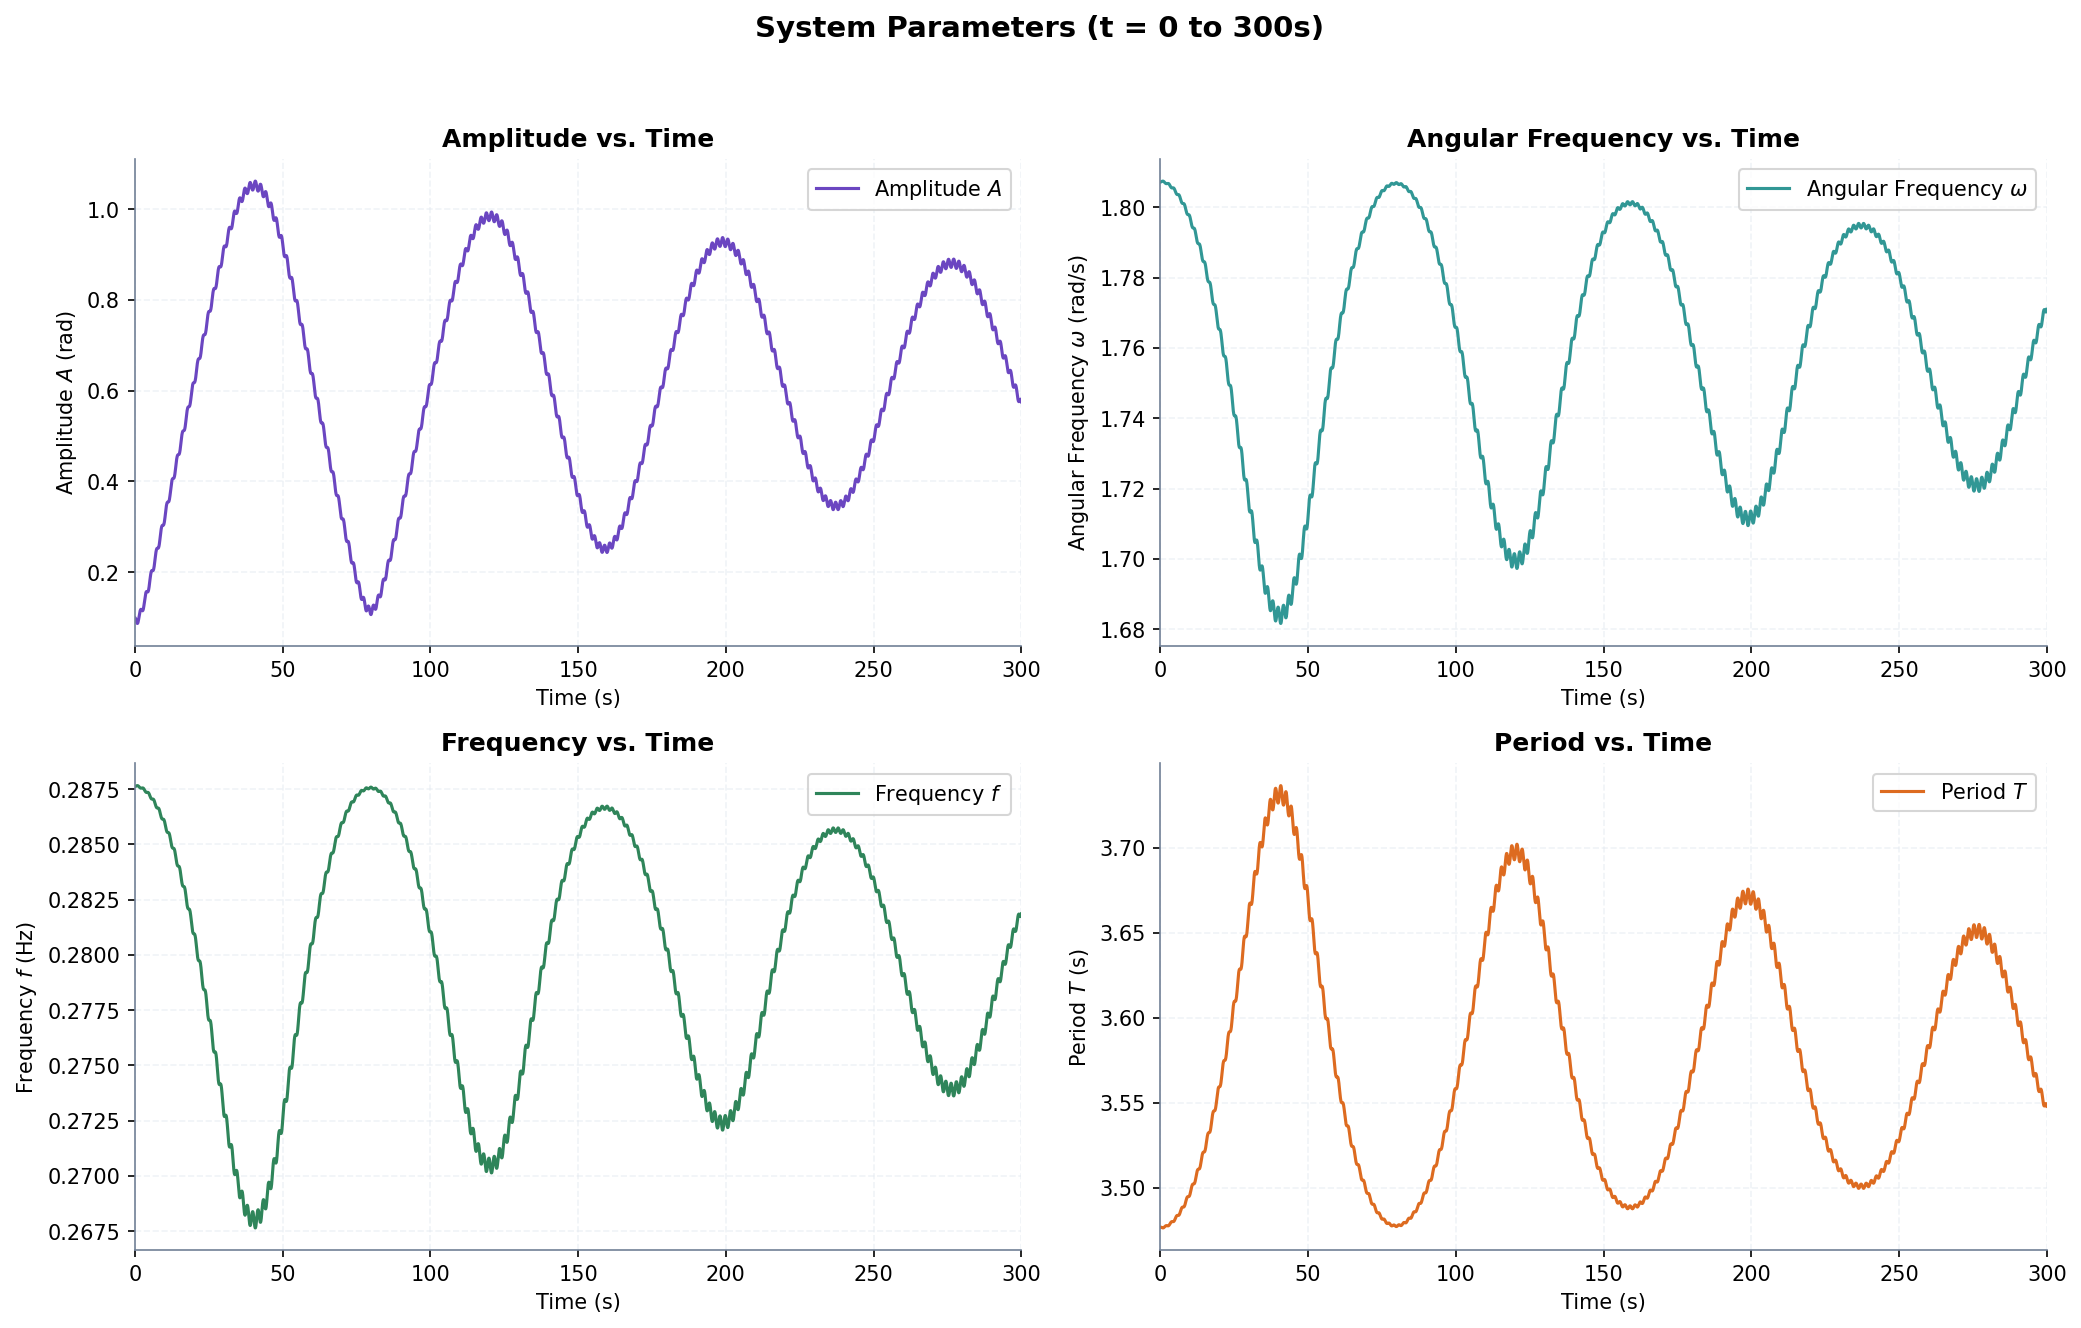
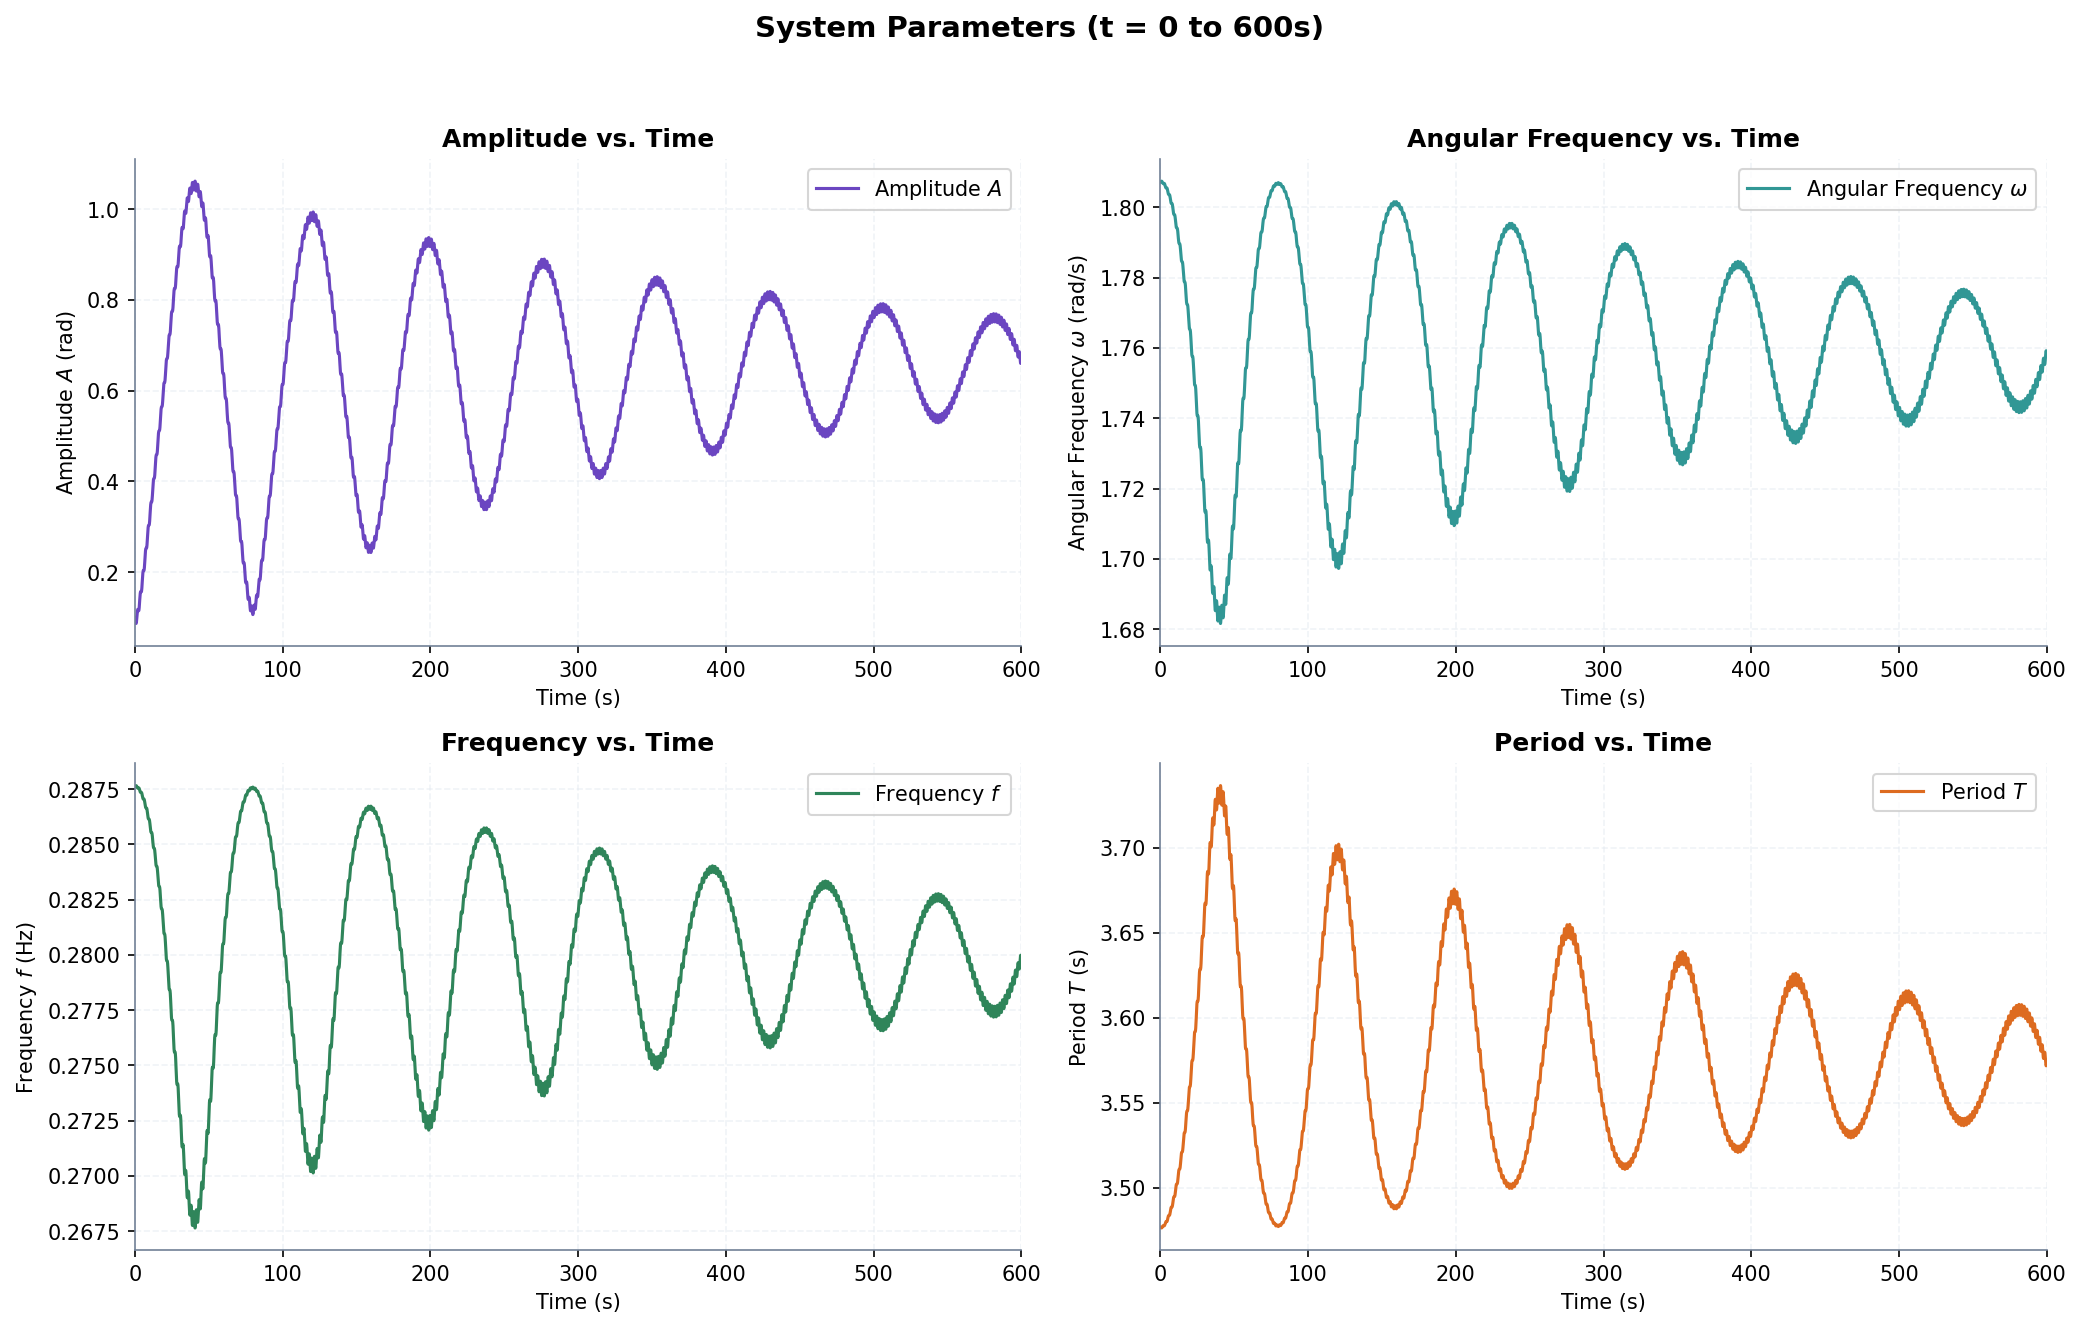
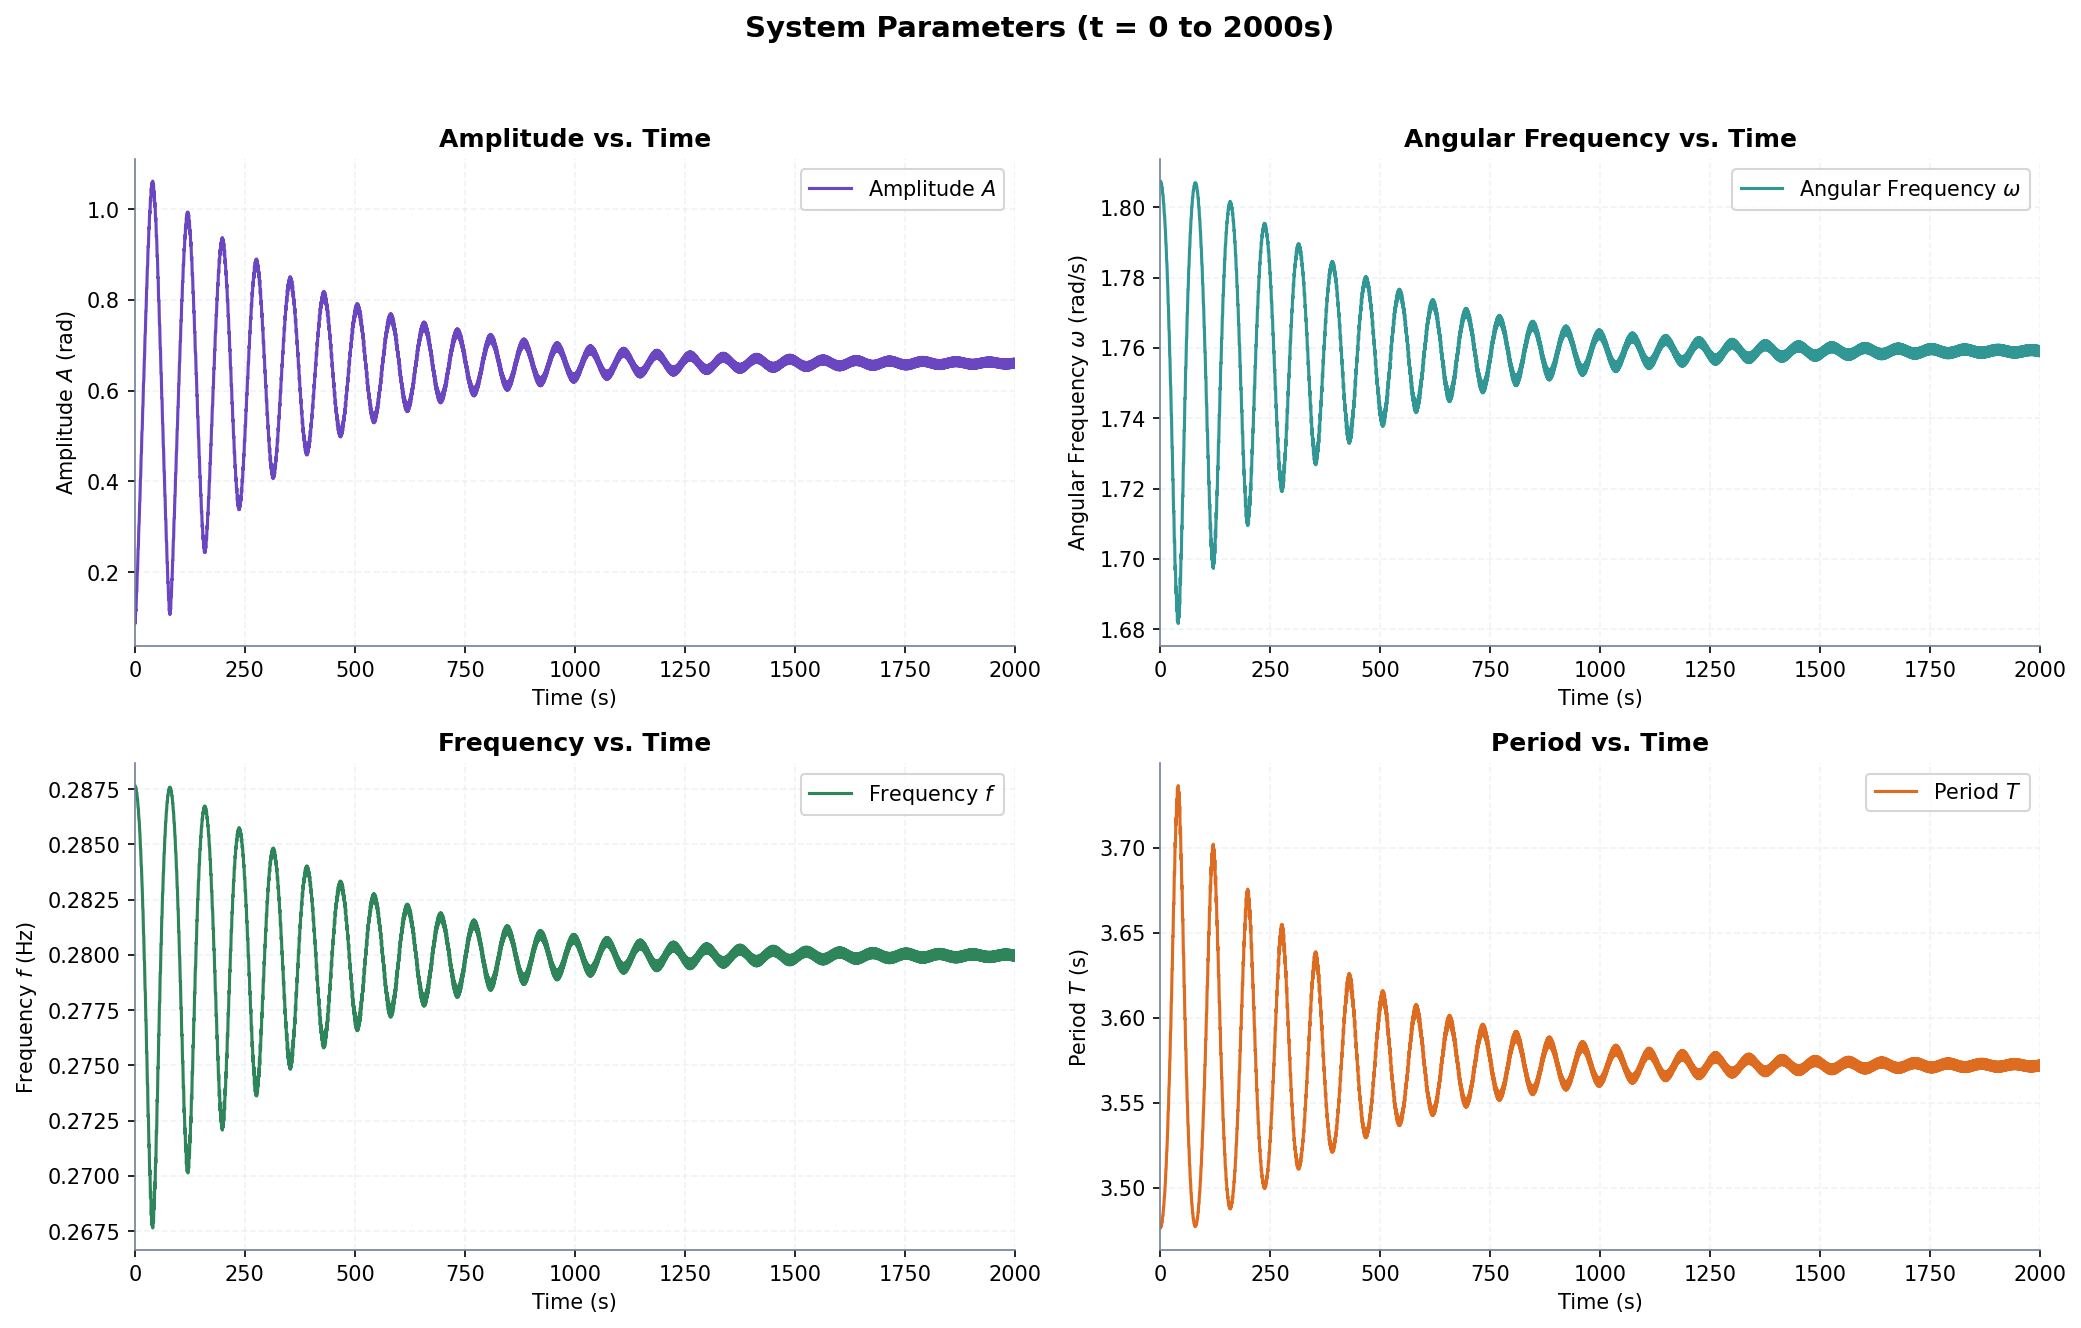

In [3]:
# Load system parameters data
df_amplitude = pd.read_csv("data/t_vs_amplitude.csv")
df_omega = pd.read_csv("data/t_vs_omega.csv")
df_freq = pd.read_csv("data/t_vs_freq.csv")
df_T = pd.read_csv("data/t_vs_T.csv")

amplitude = df_amplitude["amplitude"].values
omega = df_omega["omega"].values
freq = df_freq["freq"].values
T = df_T["T"].values

COLORS.update({
    'amplitude': '#6B46C1',
    'omega': '#319795',
    'freq': '#2F855A',
    'period': '#DD6B20'
})

param_limits = [300, 600, 2000]
param_files = []
for t_max in param_limits:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax in axes.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.5, color=COLORS['grid'])
        
    # Amplitude
    axes[0, 0].plot(t, amplitude, color=COLORS['amplitude'], linewidth=1.5, label='Amplitude $A$')
    axes[0, 0].set_title('Amplitude vs. Time', fontweight='bold')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel(r'Amplitude $A$ (rad)')
    axes[0, 0].set_xlim(0, t_max)
    axes[0, 0].legend(loc='upper right')
    
    # Angular Frequency
    axes[0, 1].plot(t, omega, color=COLORS['omega'], linewidth=1.5, label=r'Angular Frequency $\omega$')
    axes[0, 1].set_title('Angular Frequency vs. Time', fontweight='bold')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel(r'Angular Frequency $\omega$ (rad/s)')
    axes[0, 1].set_xlim(0, t_max)
    axes[0, 1].legend(loc='upper right')
    
    # Frequency
    axes[1, 0].plot(t, freq, color=COLORS['freq'], linewidth=1.5, label='Frequency $f$')
    axes[1, 0].set_title('Frequency vs. Time', fontweight='bold')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Frequency $f$ (Hz)')
    axes[1, 0].set_xlim(0, t_max)
    axes[1, 0].legend(loc='upper right')
    
    # Period
    axes[1, 1].plot(t, T, color=COLORS['period'], linewidth=1.5, label='Period $T$')
    axes[1, 1].set_title('Period vs. Time', fontweight='bold')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Period $T$ (s)')
    axes[1, 1].set_xlim(0, t_max)
    axes[1, 1].legend(loc='upper right')
    
    fig.suptitle(f'System Parameters (t = 0 to {t_max}s)', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fn = f"plots/params_nb_0_{t_max}.png"
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.close(fig)
    param_files.append(fn)

display_carousel(param_files, [f'Parameters (0 to {x}s)' for x in param_limits])

### Observations
- Crests and troughs of the amplitude, period, frequency, and angular frequency graphs shrink to give constant values of about 0.7 rad, 3.555s, 0.28Hz, and 1.76 rad/s.
- The period is affected more by damping than by the driving force, evident by the greater decay of the upper envelope than the growth of the lower envelope.
- The amplitude, frequency, and angular frequency are affected more by the driving force than by damping, as evident in the boundary trends.


## Phase-Space Analysis


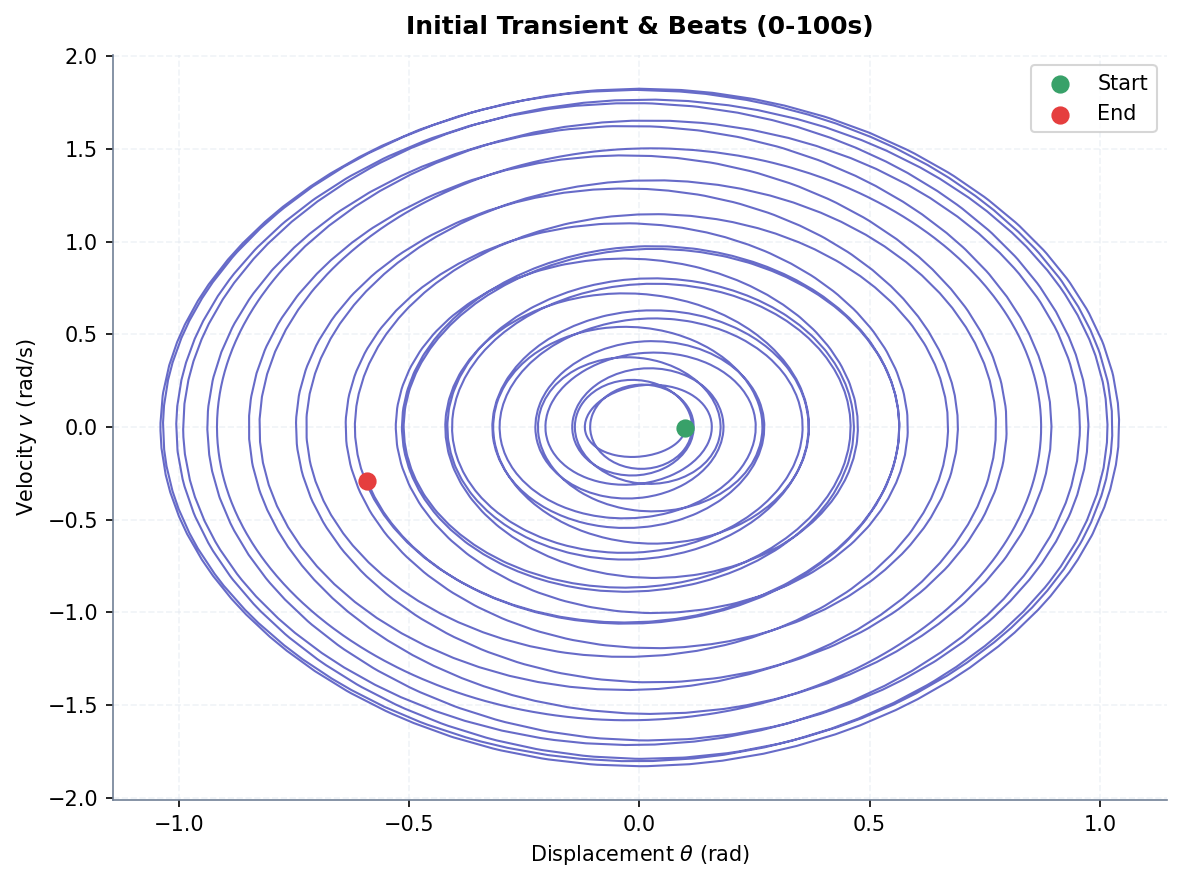
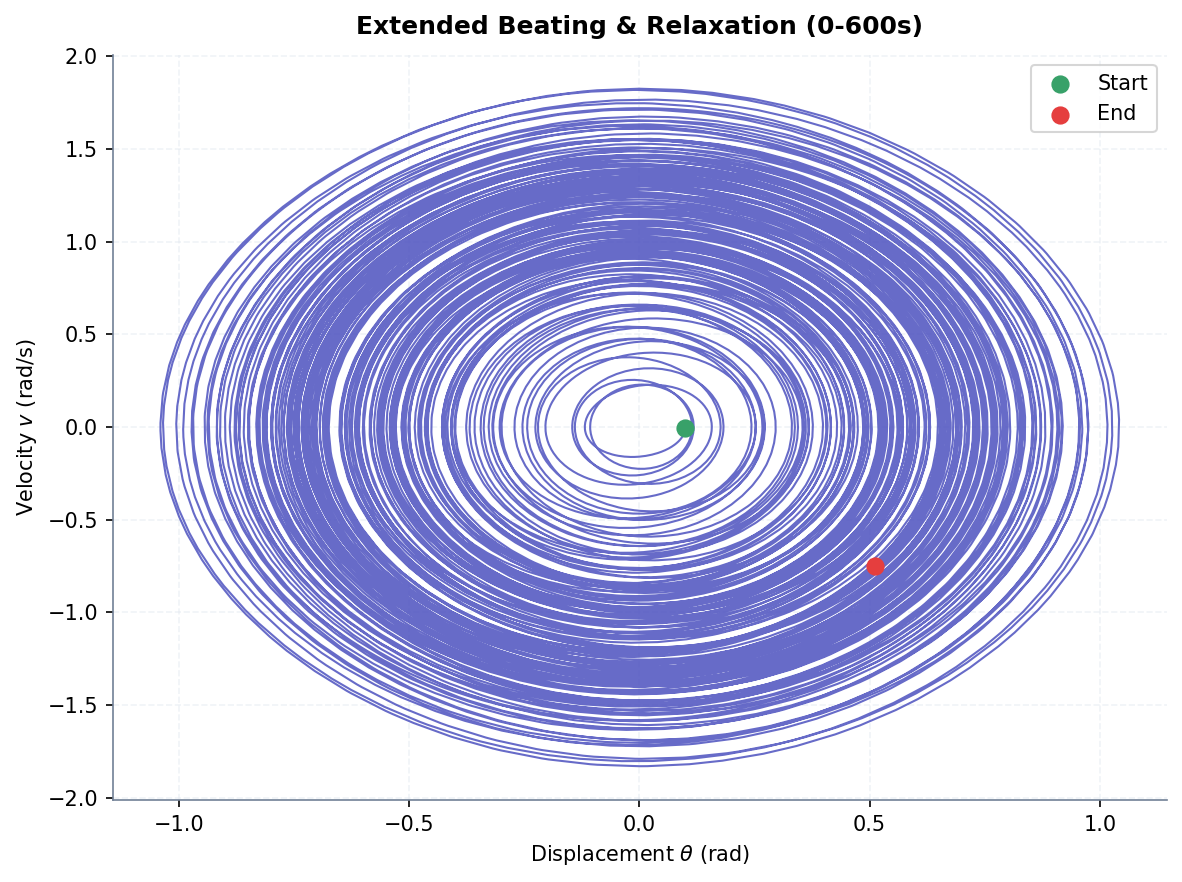
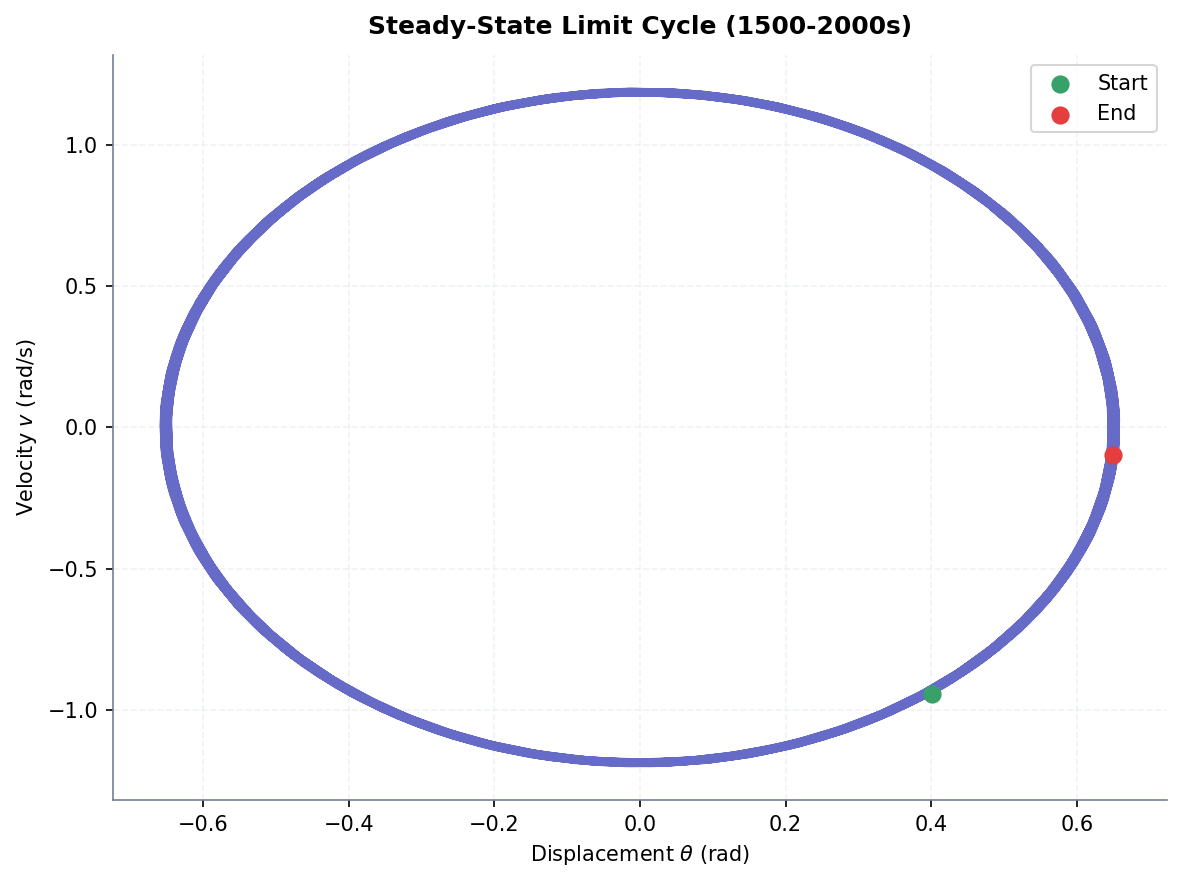

In [4]:
# Load phase-space data
df_phase = pd.read_csv("data/phase_space.csv")
theta_phase = df_phase["theta"].values
v_phase = df_phase["v"].values

phase_files = []
# Generate three different phase space plots to show transient decay, beats, and the limit cycle
time_windows = [
    (0, 100, "Initial Transient & Beats (0-100s)", "plots/phase_nb_0_100.png"),
    (0, 600, "Extended Beating & Relaxation (0-600s)", "plots/phase_nb_0_600.png"),
    (1500, 2000, "Steady-State Limit Cycle (1500-2000s)", "plots/phase_nb_1500_2000.png")
]

for t_start, t_end, title, fn in time_windows:
    # Filter indices based on time
    idx_filter = (t >= t_start) & (t <= t_end)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.5, color=COLORS['grid'])
    
    # Plot trajectory
    ax.plot(theta_phase[idx_filter], v_phase[idx_filter], color='#4C51BF', linewidth=1.0, alpha=0.85)
    
    # Highlight starting and ending points
    t_indices = np.where(idx_filter)[0]
    if len(t_indices) > 0:
        ax.scatter(theta_phase[t_indices[0]], v_phase[t_indices[0]], color='#38A169', s=60, zorder=5, label='Start')
        ax.scatter(theta_phase[t_indices[-1]], v_phase[t_indices[-1]], color='#E53E3E', s=60, zorder=5, label='End')
        
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Displacement $\\theta$ (rad)', fontsize=10)
    ax.set_ylabel('Velocity $v$ (rad/s)', fontsize=10)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.close(fig)
    phase_files.append(fn)

display_carousel(phase_files, [title for _, _, title, _ in time_windows])

### Observations from Phase-Space Graph
- At the start (0 to 100s), the graph of velocity vs displacement reaches the greatest velocities and displacements.
- Over 0 to 600s, the graph begins to concentrate in the middle.
- From 1500 to 2000s, the loops settle into a single stable track - evidence of the stabilization of energy.
